# 01 — Data Preprocessing & EDA

## 1. Load libraries and dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Upload/use your Telco_customer_churn.xlsx file
df = pd.read_excel("/content/Telco_customer_churn.xlsx")

print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

None

## 2. Data understanding

In [4]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Constant columns:", constant_cols)

for col in ["Count", "Country"]:
    if col in df.columns:
        print(f"\n{col} unique values:", df[col].nunique(dropna=False))
        display(df[col].value_counts(dropna=False).head(10))

Shape: (7043, 33)

Data types:


,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object



Missing values:


,0
Churn Reason,5174
CustomerID,0
Count,0
State,0
Country,0
Zip Code,0
Lat Long,0
Latitude,0
City,0
Gender,0



Duplicate rows: 0
Constant columns: ['Count', 'Country', 'State']

Count unique values: 1


,count
Count,
1,7043



Country unique values: 1


,count
Country,
United States,7043


## 3. Clean missing values and data types

In [5]:
# Common Telco dataset issue: Total Charges may contain blanks/spaces
if "Total Charges" in df.columns:
    df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# Convert common binary Yes/No columns to clean strings while preserving categories
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

print("Missing values after type conversion:")
display(df.isna().sum().sort_values(ascending=False).head(15))

# Median imputation for numeric columns
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

df = df.drop_duplicates().reset_index(drop=True)

print("Cleaned shape:", df.shape)
display(df.head())

Missing values after type conversion:


,0
Churn Reason,5174
Total Charges,11
CustomerID,0
Count,0
Country,0
Zip Code,0
Lat Long,0
State,0
City,0
Gender,0


Cleaned shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


## 4. Outlier detection and treatment

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

outlier_summary = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, lower, upper, int(n)])

outlier_summary = pd.DataFrame(outlier_summary, columns=["Feature","Lower","Upper","Outliers"])
display(outlier_summary)

# Winsorize numeric outliers using IQR bounds
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    df[col] = df[col].clip(lower, upper)

,Feature,Lower,Upper,Outliers
0,Count,1.000000,1.000000,0
1,Zip Code,87228.500000,100224.500000,0
2,Latitude,27.739984,44.515800,0
3,Longitude,-127.473674,-112.384975,0
4,Tenure Months,-60.000000,124.000000,0
5,Monthly Charges,-46.025000,171.375000,0
6,Total Charges,-4674.337500,8863.162500,0
7,Churn Value,-1.500000,2.500000,0
8,Churn Score,-12.500000,127.500000,0
9,CLTV,601.750000,8247.750000,0


## 5. Exploratory Data Analysis

Churn distribution:


,count
Churn Label,
No,5174
Yes,1869


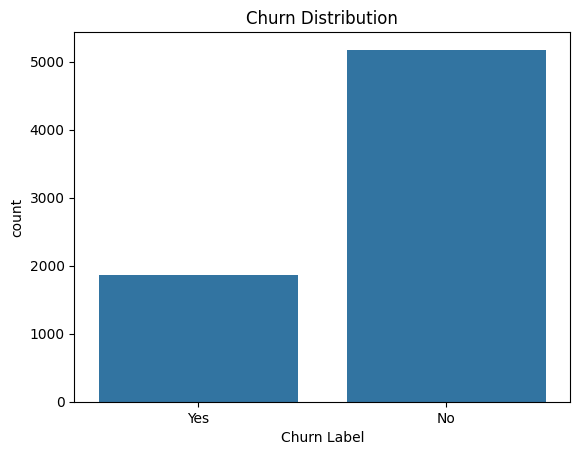

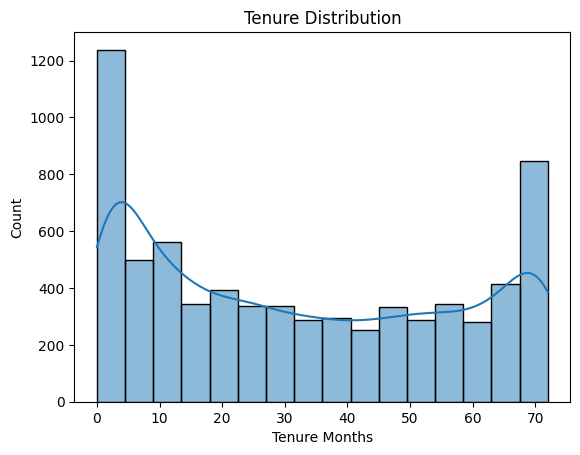

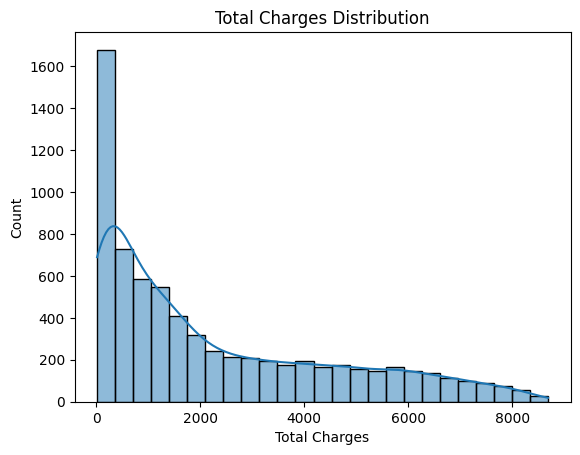

In [7]:
if "Churn Label" in df.columns:
    print("Churn distribution:")
    display(df["Churn Label"].value_counts())
    sns.countplot(data=df, x="Churn Label")
    plt.title("Churn Distribution")
    plt.show()

if "Tenure Months" in df.columns:
    sns.histplot(data=df, x="Tenure Months", kde=True)
    plt.title("Tenure Distribution")
    plt.show()

if "Monthly Charge" in df.columns:
    sns.boxplot(data=df, x="Churn Label" if "Churn Label" in df.columns else None,
                y="Monthly Charge")
    plt.title("Monthly Charge vs Churn")
    plt.show()

if "Total Charges" in df.columns:
    sns.histplot(data=df, x="Total Charges", kde=True)
    plt.title("Total Charges Distribution")
    plt.show()

## 6. Correlation matrix

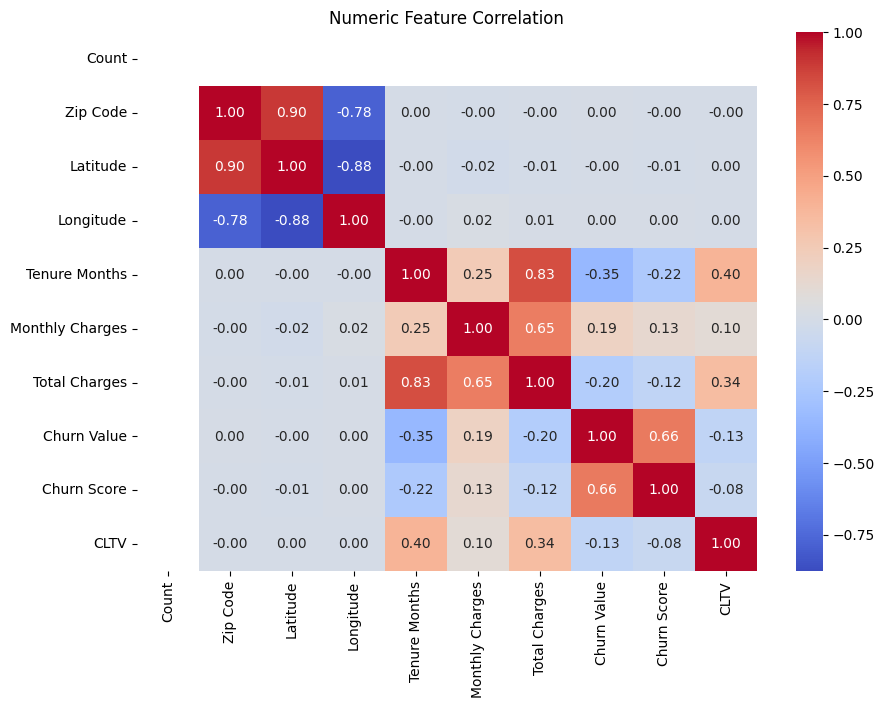

In [8]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Numeric Feature Correlation")
plt.show()

## 7. Save cleaned dataset

In [9]:
CLEAN_PATH = "telco_cleaned.csv"
df.to_csv(CLEAN_PATH, index=False)
print("Saved:", CLEAN_PATH)

Saved: telco_cleaned.csv
